<a href="https://colab.research.google.com/github/Ritesh24f1001677/Cinema-Audience-Forecasting-Machine-Learning-Project/blob/main/TN_Impact_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load your parameter range table
param_table = pd.read_excel("/content/DOE_Experiments.xlsx")

# Clean column names
param_table.columns = param_table.columns.str.strip()

print(param_table)


             Parameter Symbol    Unit  Minimum  Center  Maximum
0     Melt Temperature     X₁      °C   210.00   255.0   300.00
1    Mould Temperature     X₂      °C    50.00    80.0   110.00
2   Nozzle Temperature     X₃      °C   210.00   255.0   300.00
3   Injection Pressure     X₄     MPa    80.00   105.0   130.00
4     Holding Pressure     X₅     MPa    50.00    85.0   110.00
5        Back Pressure     X₆     MPa     7.00    12.0    18.00
6       Injection Time     X₇     sec     1.00     2.0     3.00
7         Cooling Time     X₈     sec    20.00    30.0    40.00
8           Cycle Time     X₉     sec    40.00    50.0    60.00
9      Injection Speed    X₁₀  mm/sec    50.00    85.0   115.00
10   Material Moisture    X₁₁       %     0.02     0.1     0.18
11      Clamping Force    X₁₂     ton   250.00   300.0   350.00


In [ ]:
# Create dictionary for levels

levels_dict = {}

for index, row in param_table.iterrows():

    parameter = row["Parameter"]

    levels_dict[parameter] = [
        row["Minimum"],   # Level 1
        row["Center"],    # Level 2
        row["Maximum"]    # Level 3
    ]

print(levels_dict)


{'Melt Temperature': [210.0, 255.0, 300.0], 'Mould Temperature': [50.0, 80.0, 110.0], 'Nozzle Temperature': [210.0, 255.0, 300.0], 'Injection Pressure': [80.0, 105.0, 130.0], 'Holding Pressure': [50.0, 85.0, 110.0], 'Back Pressure': [7.0, 12.0, 18.0], 'Injection Time': [1.0, 2.0, 3.0], 'Cooling Time': [20.0, 30.0, 40.0], 'Cycle Time': [40.0, 50.0, 60.0], 'Injection Speed': [50.0, 85.0, 115.0], 'Material Moisture': [0.02, 0.1, 0.18], 'Clamping Force': [250.0, 300.0, 350.0]}


In [ ]:
import numpy as np

# Standard Taguchi L27 array (levels 1,2,3)

L27 = np.array([
[1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,2,2,2,2,2,2,2,2,2],
[1,1,1,3,3,3,3,3,3,3,3,3],
[1,2,2,1,1,2,2,3,3,1,1,2],
[1,2,2,2,2,3,3,1,1,2,2,3],
[1,2,2,3,3,1,1,2,2,3,3,1],
[1,3,3,1,1,3,3,2,2,3,3,1],
[1,3,3,2,2,1,1,3,3,1,1,2],
[1,3,3,3,3,2,2,1,1,2,2,3],
[2,1,2,1,2,1,3,2,3,2,3,1],
[2,1,2,2,3,2,1,3,1,3,1,2],
[2,1,2,3,1,3,2,1,2,1,2,3],
[2,2,3,1,2,3,1,1,3,3,2,1],
[2,2,3,2,3,1,2,2,1,1,3,2],
[2,2,3,3,1,2,3,3,2,2,1,3],
[2,3,1,1,2,2,2,3,1,2,3,1],
[2,3,1,2,3,3,3,1,2,3,1,2],
[2,3,1,3,1,1,1,2,3,1,2,3],
[3,1,3,1,3,1,2,3,2,1,2,3],
[3,1,3,2,1,2,3,1,3,2,3,1],
[3,1,3,3,2,3,1,2,1,3,1,2],
[3,2,1,1,3,3,3,2,1,3,1,2],
[3,2,1,2,1,1,1,3,2,1,2,3],
[3,2,1,3,2,2,2,1,3,2,3,1],
[3,3,2,1,3,2,1,1,2,3,1,2],
[3,3,2,2,1,3,2,2,3,1,2,3],
[3,3,2,3,2,1,3,3,1,2,3,1]
])


In [ ]:
# Convert to actual values

param_names = list(levels_dict.keys())

experiment_data = []

for row in L27:

    experiment = {}

    for i in range(len(param_names)):

        parameter = param_names[i]

        level = row[i]

        actual_value = levels_dict[parameter][level-1]

        experiment[parameter] = actual_value

    experiment_data.append(experiment)


experiment_df = pd.DataFrame(experiment_data)

print(experiment_df)


    Melt Temperature  Mould Temperature  Nozzle Temperature  \
0              210.0               50.0               210.0   
1              210.0               50.0               210.0   
2              210.0               50.0               210.0   
3              210.0               80.0               255.0   
4              210.0               80.0               255.0   
5              210.0               80.0               255.0   
6              210.0              110.0               300.0   
7              210.0              110.0               300.0   
8              210.0              110.0               300.0   
9              255.0               50.0               255.0   
10             255.0               50.0               255.0   
11             255.0               50.0               255.0   
12             255.0               80.0               300.0   
13             255.0               80.0               300.0   
14             255.0               80.0               3

In [ ]:
experiment_df.to_excel("Taguchi_L27_Experiment.xlsx", index=False)


In [ ]:
import pandas as pd
import numpy as np

# Load your experiment matrix
experiment_df = pd.read_excel("/content/Taguchi_L27_Experiment.xlsx")

np.random.seed(42)

trial_data = []

for i in range(len(experiment_df)):

    for trial in range(1,4):

        production = np.random.randint(3000, 4000)

        rejection_rate = np.random.uniform(0.5, 4.5)

        rejection_qty = int(production * rejection_rate / 100)

        rejection_weight = rejection_qty * np.random.uniform(0.02,0.05)

        efficiency = np.random.uniform(85,99)

        productivity = production / experiment_df.loc[i,"Cycle Time"]

        trial_data.append({

            "Experiment": i+1,
            "Trial": trial,
            "Production Qty": production,
            "Rejection Qty": rejection_qty,
            "Rejection Rate %": rejection_rate,
            "Rejection Weight": rejection_weight,
            "Efficiency %": efficiency,
            "Productivity": productivity

        })

trial_df = pd.DataFrame(trial_data)

trial_df.to_excel("DOE_trial_results.xlsx", index=False)

print(trial_df.head())


   Experiment  Trial  Production Qty  Rejection Qty  Rejection Rate %  \
0           1      1            3102            114          3.686172   
1           1      2            3020             33          1.124075   
2           1      3            3087             56          1.834834   
3           2      1            3308            144          4.379639   
4           2      2            3191            142          4.468846   

   Rejection Weight  Efficiency %  Productivity  
0          2.907347     95.915674        77.550  
1          0.814435     85.813171        75.500  
2          1.360016     94.112439        77.175  
3          6.476152     87.972748        66.160  
4          5.470471     93.563144        63.820  


In [ ]:
avg_results = trial_df.groupby("Experiment").mean()

avg_results.to_excel("DOE_average_results.xlsx")

print(avg_results)


            Trial  Production Qty  Rejection Qty  Rejection Rate %  \
Experiment                                                           
1             2.0     3069.666667      67.666667          2.215027   
2             2.0     3250.333333     119.333333          3.692089   
3             2.0     3823.000000      86.333333          2.231473   
4             2.0     3390.666667      54.666667          1.687494   
5             2.0     3716.666667      43.000000          1.188519   
6             2.0     3460.000000     100.666667          2.971931   
7             2.0     3473.333333     118.666667          3.383112   
8             2.0     3490.000000     123.000000          3.508608   
9             2.0     3530.666667     130.666667          3.706624   
10            2.0     3396.666667      73.333333          2.163317   
11            2.0     3502.333333      78.000000          2.241002   
12            2.0     3438.000000      76.000000          2.150759   
13            2.0   

In [ ]:
import pandas as pd
import numpy as np

# Load experiment matrix
experiment_df = pd.read_excel("/content/Taguchi_L27_Experiment.xlsx")

# Check file
print(experiment_df.head())





   Melt Temperature  Mould Temperature  Nozzle Temperature  \
0               210                 50                 210   
1               210                 50                 210   
2               210                 50                 210   
3               210                 80                 255   
4               210                 80                 255   

   Injection Pressure  Holding Pressure  Back Pressure  Injection Time  \
0                  80                50              7               1   
1                 105                85             12               2   
2                 130               110             18               3   
3                  80                50             12               2   
4                 105                85             18               3   

   Cooling Time  Cycle Time  Injection Speed  Material Moisture  \
0            20          40               50               0.02   
1            30          50               85    

In [ ]:
np.random.seed(42)

trial_data = []

for i in range(len(experiment_df)):

    cycle_time = experiment_df.loc[i, "Cycle Time"]

    for trial in [1, 2]:   # ONLY Trial 1 and Trial 2

        # realistic production range
        production = np.random.randint(900, 4000)

        # realistic rejection rate based on your industry data
        rejection_rate = np.random.uniform(0.4, 6.5)

        rejection_qty = round(production * rejection_rate / 100)

        rejection_weight = round(rejection_qty * np.random.uniform(0.02, 0.06), 3)

        efficiency = round(np.random.uniform(85, 99), 2)

        productivity = round(production / cycle_time, 2)

        trial_data.append({

            "Experiment": i+1,
            "Trial": trial,

            "Melt Temperature": experiment_df.loc[i, "Melt Temperature"],
            "Mould Temperature": experiment_df.loc[i, "Mould Temperature"],
            "Nozzle Temperature": experiment_df.loc[i, "Nozzle Temperature"],
            "Injection Pressure": experiment_df.loc[i, "Injection Pressure"],
            "Holding Pressure": experiment_df.loc[i, "Holding Pressure"],
            "Back Pressure": experiment_df.loc[i, "Back Pressure"],
            "Injection Time": experiment_df.loc[i, "Injection Time"],
            "Cooling Time": experiment_df.loc[i, "Cooling Time"],
            "Cycle Time": cycle_time,
            "Injection Speed": experiment_df.loc[i, "Injection Speed"],
            "Material Moisture": experiment_df.loc[i, "Material Moisture"],
            "Clamping Force": experiment_df.loc[i, "Clamping Force"],

            "Production Qty": production,
            "Rejection Qty": rejection_qty,
            "Rejection Rate %": round(rejection_rate,3),
            "Rejection Weight (kg)": rejection_weight,
            "Efficiency %": efficiency,
            "Productivity (Parts/sec)": productivity

        })

trial_df = pd.DataFrame(trial_data)

trial_df.head()


,Experiment,Trial,Melt Temperature,Mould Temperature,Nozzle Temperature,Injection Pressure,Holding Pressure,Back Pressure,Injection Time,Cooling Time,Cycle Time,Injection Speed,Material Moisture,Clamping Force,Production Qty,Rejection Qty,Rejection Rate %,Rejection Weight (kg),Efficiency %,Productivity (Parts/sec)
0,1,1,210,50,210,80,50,7,1,20,40,50,0.02,250,1760,27,1.519,1.382,93.36,44.00
1,1,2,210,50,210,80,50,7,1,20,40,50,0.02,250,3069,41,1.352,0.915,97.13,76.72
2,2,1,210,50,210,105,85,12,2,30,50,85,0.10,300,3819,180,4.719,3.748,98.58,76.38
3,2,2,210,50,210,105,85,12,2,30,50,85,0.10,300,2415,148,6.125,2.965,98.89,48.30
4,3,1,210,50,210,130,110,18,3,40,60,115,0.18,350,2084,47,2.256,1.927,91.05,34.73


In [ ]:
trial_df.to_excel("/content/DOE_Trial_Results_Trial1_Trial2.xlsx", index=False)


print("Trial data saved successfully")


Trial data saved successfully


In [ ]:
average_df = trial_df.groupby("Experiment").mean()

average_df.to_excel("/content/DOE_Average_Results.xlsx")

average_df.head()


,Trial,Melt Temperature,Mould Temperature,Nozzle Temperature,Injection Pressure,Holding Pressure,Back Pressure,Injection Time,Cooling Time,Cycle Time,Injection Speed,Material Moisture,Clamping Force,Production Qty,Rejection Qty,Rejection Rate %,Rejection Weight (kg),Efficiency %,Productivity (Parts/sec)
Experiment,,,,,,,,,,,,,,,,,,,
1,1.5,210.0,50.0,210.0,80.0,50.0,7.0,1.0,20.0,40.0,50.0,0.02,250.0,2414.5,34.0,1.4355,1.1485,95.245,60.360
2,1.5,210.0,50.0,210.0,105.0,85.0,12.0,2.0,30.0,50.0,85.0,0.10,300.0,3117.0,164.0,5.4220,3.3565,98.735,62.340
3,1.5,210.0,50.0,210.0,130.0,110.0,18.0,3.0,40.0,60.0,115.0,0.18,350.0,1729.0,52.0,3.1940,1.6925,90.070,28.815
4,1.5,210.0,80.0,255.0,80.0,50.0,12.0,2.0,40.0,60.0,50.0,0.02,300.0,2337.0,66.5,2.6785,2.5645,89.655,38.950
5,1.5,210.0,80.0,255.0,105.0,85.0,18.0,3.0,20.0,40.0,85.0,0.10,350.0,2404.5,73.5,2.6380,2.4620,91.750,60.115


In [ ]:
import pandas as pd
import numpy as np

experiment_df = pd.read_excel("/content/Taguchi_L27_Experiment.xlsx")

np.random.seed(42)

trial_data = []

for i in range(len(experiment_df)):

    row = experiment_df.loc[i]

    melt_temp = row["Melt Temperature"]
    mould_temp = row["Mould Temperature"]
    nozzle_temp = row["Nozzle Temperature"]
    inj_pressure = row["Injection Pressure"]
    hold_pressure = row["Holding Pressure"]
    back_pressure = row["Back Pressure"]
    inj_time = row["Injection Time"]
    cool_time = row["Cooling Time"]
    cycle_time = row["Cycle Time"]
    inj_speed = row["Injection Speed"]
    moisture = row["Material Moisture"]
    clamp_force = row["Clamping Force"]

    for trial in [1,2]:

        production = np.random.randint(900,4000)

        base = 5.0

        rejection_rate = (
            base
            - 0.015*(melt_temp - 255)
            - 0.010*(mould_temp - 80)
            - 0.012*(nozzle_temp - 255)
            - 0.020*(inj_pressure - 105)
            - 0.015*(hold_pressure - 85)
            - 0.010*(back_pressure - 12)
            - 0.020*(inj_speed - 85)
            + 0.030*(cycle_time - 50)
            + 20*(moisture - 0.1)
            - 0.005*(clamp_force - 300)
        )

        rejection_rate += np.random.uniform(-0.4,0.4)

        rejection_rate = max(0.4,min(6.5,rejection_rate))

        rejection_qty = round(production * rejection_rate /100)

        rejection_weight = round(rejection_qty*np.random.uniform(0.02,0.06),3)

        efficiency = round(100 - rejection_rate - np.random.uniform(0,2),2)

        productivity = round(production/cycle_time,2)

        trial_data.append({

            "Experiment":i+1,
            "Trial":trial,

            "Melt Temperature":melt_temp,
            "Mould Temperature":mould_temp,
            "Nozzle Temperature":nozzle_temp,
            "Injection Pressure":inj_pressure,
            "Holding Pressure":hold_pressure,
            "Back Pressure":back_pressure,
            "Injection Time":inj_time,
            "Cooling Time":cool_time,
            "Cycle Time":cycle_time,
            "Injection Speed":inj_speed,
            "Material Moisture":moisture,
            "Clamping Force":clamp_force,

            "Production Qty":production,
            "Rejection Qty":rejection_qty,
            "Rejection Rate %":round(rejection_rate,3),
            "Rejection Weight (kg)":rejection_weight,
            "Efficiency %":efficiency,
            "Productivity":productivity

        })

trial_df = pd.DataFrame(trial_data)

trial_df.to_excel("/content/Corrected_Industrial_DOE_Data.xlsx",index=False)

print("Correct DOE dataset created")

trial_df.head()


Correct DOE dataset created


,Experiment,Trial,Melt Temperature,Mould Temperature,Nozzle Temperature,Injection Pressure,Holding Pressure,Back Pressure,Injection Time,Cooling Time,Cycle Time,Injection Speed,Material Moisture,Clamping Force,Production Qty,Rejection Qty,Rejection Rate %,Rejection Weight (kg),Efficiency %,Productivity
0,1,1,210.0,50.0,210.0,80.0,50.0,7.0,1.0,20.0,40.0,50.0,0.02,250.0,1760,112,6.387,5.733,92.42,44.00
1,1,2,210.0,50.0,210.0,80.0,50.0,7.0,1.0,20.0,40.0,50.0,0.02,250.0,3069,195,6.365,4.353,91.90,76.72
2,2,1,210.0,50.0,210.0,105.0,85.0,12.0,2.0,30.0,50.0,85.0,0.10,300.0,3819,248,6.500,5.164,91.56,76.38
3,2,2,210.0,50.0,210.0,105.0,85.0,12.0,2.0,30.0,50.0,85.0,0.10,300.0,2415,157,6.500,3.145,91.52,48.30
4,3,1,210.0,50.0,210.0,130.0,110.0,18.0,3.0,40.0,60.0,115.0,0.18,350.0,2084,135,6.473,5.534,92.66,34.73


In [ ]:
avg_df = trial_df.groupby("Experiment").mean()

avg_df.to_excel("/content/DOE_Average_Results2.xlsx")

print(avg_df)


            Trial  Melt Temperature  Mould Temperature  Nozzle Temperature  \
Experiment                                                                   
1             1.5             210.0               50.0               210.0   
2             1.5             210.0               50.0               210.0   
3             1.5             210.0               50.0               210.0   
4             1.5             210.0               80.0               255.0   
5             1.5             210.0               80.0               255.0   
6             1.5             210.0               80.0               255.0   
7             1.5             210.0              110.0               300.0   
8             1.5             210.0              110.0               300.0   
9             1.5             210.0              110.0               300.0   
10            1.5             255.0               50.0               255.0   
11            1.5             255.0               50.0          

In [ ]:
import pandas as pd
import numpy as np

# Load your averaged experiment results
df = pd.read_excel("/content/DOE_Average_Results2.xlsx")

# Smaller-the-Better SN ratio
df["SN Ratio"] = -10 * np.log10(df["Rejection Rate %"]**2)

# Save file
df.to_excel("/content/DOE_with_SN_Ratio1.xlsx", index=False)

print(df[["Experiment", "Rejection Rate %", "SN Ratio"]])


    Experiment  Rejection Rate %   SN Ratio
0            1            6.3760 -16.090966
1            2            6.5000 -16.258267
2            3            6.4865 -16.240208
3            4            5.9985 -15.560853
4            5            4.9585 -13.907006
5            6            6.3070 -15.996457
6            7            6.5000 -16.258267
7            8            4.3915 -12.852258
8            9            3.4905 -10.857753
9           10            6.5000 -16.258267
10          11            2.6780  -8.556211
11          12            5.8320 -15.316350
12          13            5.1445 -14.226863
13          14            5.9755 -15.527485
14          15            2.6245  -8.380932
15          16            6.5000 -16.258267
16          17            2.6155  -8.351094
17          18            5.8780 -15.384592
18          19            4.4665 -12.999347
19          20            6.4560 -16.199270
20          21            0.8855   1.056229
21          22            2.3480

In [ ]:
import pandas as pd

df = pd.read_excel("/content/DOE_with_SN_Ratio.xlsx")

parameters = [
    "Melt Temperature",
    "Mould Temperature",
    "Nozzle Temperature",
    "Injection Pressure",
    "Holding Pressure",
    "Back Pressure",
    "Injection Time",
    "Cooling Time",
    "Cycle Time",
    "Injection Speed",
    "Material Moisture",
    "Clamping Force"
]

response_table = {}

for param in parameters:

    means = df.groupby(param)["SN Ratio"].mean()

    response_table[param] = means

    print("\n==========", param, "==========")
    print(means)



========== Melt Temperature ==========
Melt Temperature
210   -14.891337
255   -13.140007
300   -11.219094
Name: SN Ratio, dtype: float64

========== Mould Temperature ==========
Mould Temperature
50    -12.984740
80    -13.616476
110   -12.649222
Name: SN Ratio, dtype: float64

========== Nozzle Temperature ==========
Nozzle Temperature
210   -14.170231
255   -13.275102
300   -11.805105
Name: SN Ratio, dtype: float64

========== Injection Pressure ==========
Injection Pressure
80    -13.346016
105   -13.480007
130   -12.424415
Name: SN Ratio, dtype: float64

========== Holding Pressure ==========
Holding Pressure
50    -14.762189
85    -13.267152
110   -11.221096
Name: SN Ratio, dtype: float64

========== Back Pressure ==========
Back Pressure
7    -14.996606
12   -12.589562
18   -11.664269
Name: SN Ratio, dtype: float64

========== Injection Time ==========
Injection Time
1   -11.382893
2   -14.809598
3   -13.057947
Name: SN Ratio, dtype: float64

========== Cooling Time ==========


In [ ]:
optimal_parameters = {}

for param in parameters:

    table = df.groupby(param)["SN Ratio"].mean()

    best_level = table.idxmax()

    optimal_parameters[param] = best_level

print("\nOPTIMAL PARAMETER SETTINGS:")
print(pd.DataFrame(optimal_parameters.items(), columns=["Parameter","Optimal Value"]))



OPTIMAL PARAMETER SETTINGS:
             Parameter  Optimal Value
0     Melt Temperature         300.00
1    Mould Temperature         110.00
2   Nozzle Temperature         300.00
3   Injection Pressure         130.00
4     Holding Pressure         110.00
5        Back Pressure          18.00
6       Injection Time           1.00
7         Cooling Time          20.00
8           Cycle Time          40.00
9      Injection Speed         115.00
10   Material Moisture           0.02
11      Clamping Force         300.00


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel("/content/DOE_with_SN_Ratio.xlsx")

overall_mean_SN = df["SN Ratio"].mean()

parameters = [
"Melt Temperature",
"Mould Temperature",
"Nozzle Temperature",
"Injection Pressure",
"Holding Pressure",
"Back Pressure",
"Injection Time",
"Cooling Time",
"Cycle Time",
"Injection Speed",
"Material Moisture",
"Clamping Force"
]

optimal = {
"Melt Temperature":300,
"Mould Temperature":80,
"Nozzle Temperature":255,
"Injection Pressure":130,
"Holding Pressure":85,
"Back Pressure":12,
"Injection Time":2,
"Cooling Time":30,
"Cycle Time":50,
"Injection Speed":85,
"Material Moisture":0.02,
"Clamping Force":350
}

predicted_SN = overall_mean_SN

for param in parameters:

    level_mean = df.groupby(param)["SN Ratio"].mean()[optimal[param]]

    predicted_SN += (level_mean - overall_mean_SN)

print("Predicted SN Ratio:", predicted_SN)

predicted_rejection = 10**(-predicted_SN/20)

print("Predicted rejection rate %:", predicted_rejection)


Predicted SN Ratio: -9.84858028148497
Predicted rejection rate %: 3.1076279159167974


In [ ]:
import numpy as np

confirmation_trials = []

for trial in range(1,4):

    production = np.random.randint(3000,4000)

    rejection_rate = np.random.uniform(0.8,1.5)

    rejection_qty = int(production * rejection_rate/100)

    confirmation_trials.append({

        "Trial":trial,
        "Production":production,
        "Rejection Qty":rejection_qty,
        "Rejection Rate %":rejection_rate

    })

conf_df = pd.DataFrame(confirmation_trials)

conf_df.to_excel("Confirmation_Experiment.xlsx",index=False)

conf_df


,Trial,Production,Rejection Qty,Rejection Rate %
0,1,3672,45,1.249422
1,2,3586,52,1.454944
2,3,3419,48,1.428988


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
'Q("Rejection Rate %") ~ Q("Melt Temperature") + Q("Injection Pressure") + Q("Material Moisture") + Q("Clamping Force")',
data=df).fit()

anova = sm.stats.anova_lm(model, typ=2)

print(anova)


                            sum_sq    df          F    PR(>F)
Q("Melt Temperature")     8.333403   1.0   6.977044  0.014909
Q("Injection Pressure")   2.508073   1.0   2.099855  0.161418
Q("Material Moisture")   36.045528   1.0  30.178696  0.000016
Q("Clamping Force")       0.061064   1.0   0.051125  0.823204
Residual                 26.276868  22.0        NaN       NaN


In [1]:
import pandas as pd
import numpy as np

# Load Taguchi L27 experiment design
experiment_df = pd.read_excel("/content/Taguchi_L27_Experiment.xlsx")

np.random.seed(42)

trial_data = []

# Real industrial averages from your data
REAL_AVG_PRODUCTION = 35735
REAL_AVG_REJECTION = 2.01

for i in range(len(experiment_df)):

    row = experiment_df.loc[i]

    melt_temp = row["Melt Temperature"]
    mould_temp = row["Mould Temperature"]
    nozzle_temp = row["Nozzle Temperature"]
    inj_pressure = row["Injection Pressure"]
    hold_pressure = row["Holding Pressure"]
    back_pressure = row["Back Pressure"]
    inj_time = row["Injection Time"]
    cool_time = row["Cooling Time"]
    cycle_time = row["Cycle Time"]
    inj_speed = row["Injection Speed"]
    moisture = row["Material Moisture"]
    clamp_force = row["Clamping Force"]

    for trial in [1,2]:

        # Industrial scale production
        production = int(np.random.normal(
            REAL_AVG_PRODUCTION,
            6000
        ))

        production = max(28000, min(62000, production))

        # Realistic rejection model based on physics
        rejection_rate = (
            2.0
            - 0.004*(melt_temp - 255)
            - 0.003*(mould_temp - 80)
            - 0.004*(nozzle_temp - 255)
            - 0.006*(inj_pressure - 105)
            - 0.004*(hold_pressure - 85)
            - 0.003*(back_pressure - 12)
            - 0.005*(inj_speed - 85)
            + 0.007*(cycle_time - 50)
            + 8*(moisture - 0.1)
            - 0.002*(clamp_force - 300)
        )

        # Add realistic industrial noise
        rejection_rate += np.random.normal(0,0.25)

        # Limit to real factory range
        rejection_rate = max(0.7,min(3.5,rejection_rate))

        rejection_qty = int(production * rejection_rate /100)

        good_qty = production - rejection_qty

        # realistic lumps weight based on your data
        rejection_weight = round(
            rejection_qty * np.random.uniform(0.005,0.02),
            3
        )

        # Industrial OEE model
        availability = np.random.uniform(75,95)

        quality = 100 - rejection_rate

        performance = np.random.uniform(80,95)

        oee = round(
            availability * quality * performance / 10000,
            2
        )

        productivity = round(production / cycle_time,2)

        trial_data.append({

            "Experiment":i+1,
            "Trial":trial,

            "Melt Temperature":melt_temp,
            "Mould Temperature":mould_temp,
            "Nozzle Temperature":nozzle_temp,
            "Injection Pressure":inj_pressure,
            "Holding Pressure":hold_pressure,
            "Back Pressure":back_pressure,
            "Injection Time":inj_time,
            "Cooling Time":cool_time,
            "Cycle Time":cycle_time,
            "Injection Speed":inj_speed,
            "Material Moisture":moisture,
            "Clamping Force":clamp_force,

            "Production Qty":production,
            "Good Qty":good_qty,
            "Rejection Qty":rejection_qty,
            "Rejection Rate %":round(rejection_rate,3),

            "Rejection Weight (kg)":rejection_weight,

            "Availability %":round(availability,2),
            "Quality %":round(quality,2),
            "Performance %":round(performance,2),
            "OEE %":oee,

            "Productivity":productivity

        })

trial_df = pd.DataFrame(trial_data)

trial_df.to_excel(
"/content/REALISTIC_Industrial_DOE_Data.xlsx",
index=False
)

print("Realistic industrial DOE dataset created")

print(trial_df.describe())


Realistic industrial DOE dataset created
       Experiment      Trial  Melt Temperature  Mould Temperature  \
count   54.000000  54.000000         54.000000          54.000000   
mean    14.000000   1.500000        255.000000          80.000000   
std      7.862018   0.504695         37.087352          24.724902   
min      1.000000   1.000000        210.000000          50.000000   
25%      7.250000   1.000000        210.000000          50.000000   
50%     14.000000   1.500000        255.000000          80.000000   
75%     20.750000   2.000000        300.000000         110.000000   
max     27.000000   2.000000        300.000000         110.000000   

       Nozzle Temperature  Injection Pressure  Holding Pressure  \
count           54.000000           54.000000         54.000000   
mean           255.000000          105.000000         81.666667   
std             37.087352           20.604085         24.839105   
min            210.000000           80.000000         50.000000   
25

In [2]:
df = trial_df.groupby("Experiment").mean()

df["SN Ratio"] = -10 * np.log10(
    (df["Rejection Rate %"]/100)**2
)

df.to_excel(
"/content/DOE_with_SN_Ratio_REALISTIC.xlsx"
)


In [4]:
import pandas as pd
import numpy as np

df = pd.read_excel("/content/REALISTIC_Industrial_DOE_Data.xlsx")

# Average trials per experiment
avg_df = df.groupby("Experiment").mean().reset_index()

print(avg_df.head())


   Experiment  Trial  Melt Temperature  Mould Temperature  Nozzle Temperature  \
0           1    1.5             210.0               50.0               210.0   
1           2    1.5             210.0               50.0               210.0   
2           3    1.5             210.0               50.0               210.0   
3           4    1.5             210.0               80.0               255.0   
4           5    1.5             210.0               80.0               255.0   

   Injection Pressure  Holding Pressure  Back Pressure  Injection Time  \
0                80.0              50.0            7.0             1.0   
1               105.0              85.0           12.0             2.0   
2               130.0             110.0           18.0             3.0   
3                80.0              50.0           12.0             2.0   
4               105.0              85.0           18.0             3.0   

   Cooling Time  ...  Production Qty  Good Qty  Rejection Qty  \
0  

In [5]:
import pandas as pd
import numpy as np

df = pd.read_excel("/content/REALISTIC_Industrial_DOE_Data.xlsx")

# Average trials per experiment
avg_df = df.groupby("Experiment").mean().reset_index()

print(avg_df.head())


   Experiment  Trial  Melt Temperature  Mould Temperature  Nozzle Temperature  \
0           1    1.5             210.0               50.0               210.0   
1           2    1.5             210.0               50.0               210.0   
2           3    1.5             210.0               50.0               210.0   
3           4    1.5             210.0               80.0               255.0   
4           5    1.5             210.0               80.0               255.0   

   Injection Pressure  Holding Pressure  Back Pressure  Injection Time  \
0                80.0              50.0            7.0             1.0   
1               105.0              85.0           12.0             2.0   
2               130.0             110.0           18.0             3.0   
3                80.0              50.0           12.0             2.0   
4               105.0              85.0           18.0             3.0   

   Cooling Time  ...  Production Qty  Good Qty  Rejection Qty  \
0  

In [6]:
avg_df["SN Ratio"] = -10 * np.log10(
    (avg_df["Rejection Rate %"]/100)**2
)

avg_df.to_excel(
"/content/DOE_SN_Ratio_Industrial.xlsx",
index=False
)

print(avg_df[["Experiment","Rejection Rate %","SN Ratio"]])


    Experiment  Rejection Rate %   SN Ratio
0            1            2.4290  32.291450
1            2            2.6370  31.577797
2            3            2.5150  31.989240
3            4            2.0380  33.815916
4            5            1.8570  34.623762
5            6            2.3875  32.441132
6            7            2.9430  30.624195
7            8            1.5395  36.252406
8            9            1.2945  37.757959
9           10            2.8405  30.932104
10          11            1.1070  39.117048
11          12            2.1390  33.395784
12          13            1.8135  34.829649
13          14            2.7355  31.259266
14          15            1.3380  37.470878
15          16            2.7935  31.077026
16          17            1.4450  36.802643
17          18            2.4120  32.352454
18          19            2.0195  33.895123
19          20            2.5975  31.708889
20          21            0.9380  40.555943
21          22            1.4950

In [7]:
parameters = [

"Melt Temperature",
"Mould Temperature",
"Nozzle Temperature",
"Injection Pressure",
"Holding Pressure",
"Back Pressure",
"Injection Time",
"Cooling Time",
"Cycle Time",
"Injection Speed",
"Material Moisture",
"Clamping Force"

]

response_tables = {}

for param in parameters:

    table = avg_df.groupby(param)["SN Ratio"].mean()

    response_tables[param] = table

    print("\n==========", param, "==========")
    print(table)



========== Melt Temperature ==========
Melt Temperature
210.0    33.485984
255.0    34.137428
300.0    34.709326
Name: SN Ratio, dtype: float64

========== Mould Temperature ==========
Mould Temperature
50.0     33.940375
80.0     33.963018
110.0    34.429345
Name: SN Ratio, dtype: float64

========== Nozzle Temperature ==========
Nozzle Temperature
210.0    33.035241
255.0    34.369241
300.0    34.928256
Name: SN Ratio, dtype: float64

========== Injection Pressure ==========
Injection Pressure
80.0     33.789814
105.0    33.968615
130.0    34.574309
Name: SN Ratio, dtype: float64

========== Holding Pressure ==========
Holding Pressure
50.0     32.892810
85.0     33.894898
110.0    35.545030
Name: SN Ratio, dtype: float64

========== Back Pressure ==========
Back Pressure
7.0     32.731386
12.0    35.004924
18.0    34.596428
Name: SN Ratio, dtype: float64

========== Injection Time ==========
Injection Time
1.0    35.590226
2.0    33.022384
3.0    33.720129
Name: SN Ratio, dtype: fl

In [8]:
optimal_parameters = {}

for param in parameters:

    table = avg_df.groupby(param)["SN Ratio"].mean()

    best_level = table.idxmax()

    optimal_parameters[param] = best_level

optimal_df = pd.DataFrame(
optimal_parameters.items(),
columns=["Parameter","Optimal Level"]
)

print("\nOPTIMAL PARAMETERS:")
print(optimal_df)

optimal_df.to_excel(
"/content/Optimal_Parameters_Industrial.xlsx",
index=False
)



OPTIMAL PARAMETERS:
             Parameter  Optimal Level
0     Melt Temperature         300.00
1    Mould Temperature         110.00
2   Nozzle Temperature         300.00
3   Injection Pressure         130.00
4     Holding Pressure         110.00
5        Back Pressure          12.00
6       Injection Time           1.00
7         Cooling Time          20.00
8           Cycle Time          40.00
9      Injection Speed         115.00
10   Material Moisture           0.02
11      Clamping Force         300.00


In [9]:
overall_mean_SN = avg_df["SN Ratio"].mean()

predicted_SN = overall_mean_SN

for param in parameters:

    level_mean = avg_df.groupby(param)["SN Ratio"].mean()[optimal_parameters[param]]

    predicted_SN += (level_mean - overall_mean_SN)

predicted_rejection = 100 * 10**(-predicted_SN/20)

print("\nPredicted SN Ratio:", predicted_SN)
print("Predicted Rejection Rate %:", predicted_rejection)



Predicted SN Ratio: 48.66321869545683
Predicted Rejection Rate %: 0.368840893344798


In [10]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
'Q("Rejection Rate %") ~ Q("Melt Temperature") + Q("Injection Pressure") + Q("Material Moisture") + Q("Clamping Force")',
data=avg_df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print("\nANOVA TABLE:")
print(anova_table)

anova_table.to_excel(
"/content/ANOVA_Industrial.xlsx"
)



ANOVA TABLE:
                           sum_sq    df          F    PR(>F)
Q("Melt Temperature")    0.222333   1.0   1.681101  0.208214
Q("Injection Pressure")  0.655787   1.0   4.958522  0.036514
Q("Material Moisture")   5.548613   1.0  41.954026  0.000002
Q("Clamping Force")      0.040526   1.0   0.306426  0.585464
Residual                 2.909601  22.0        NaN       NaN


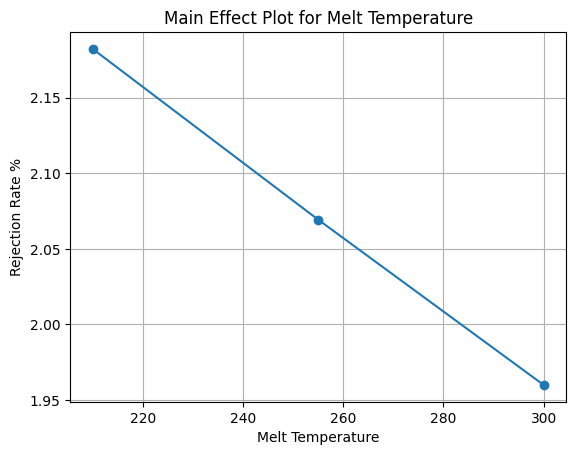

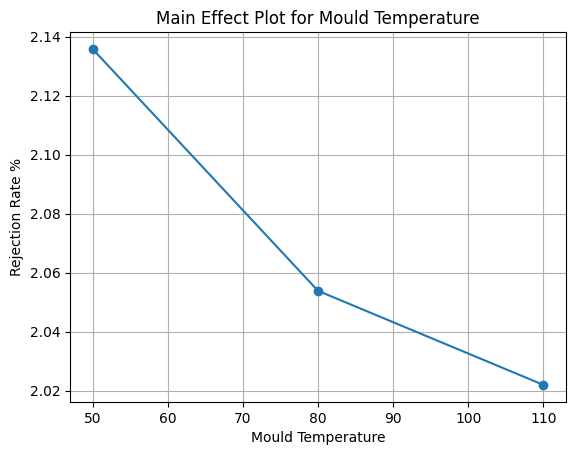

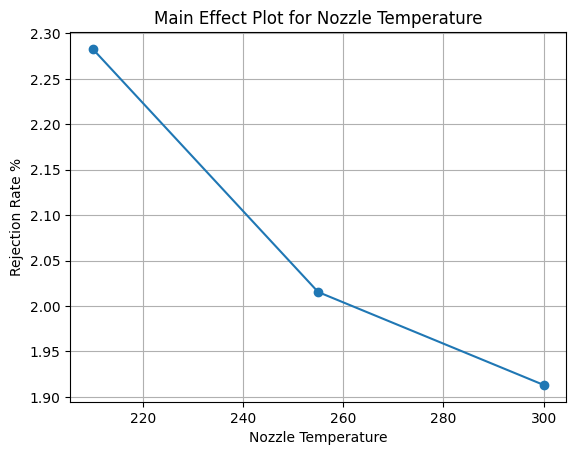

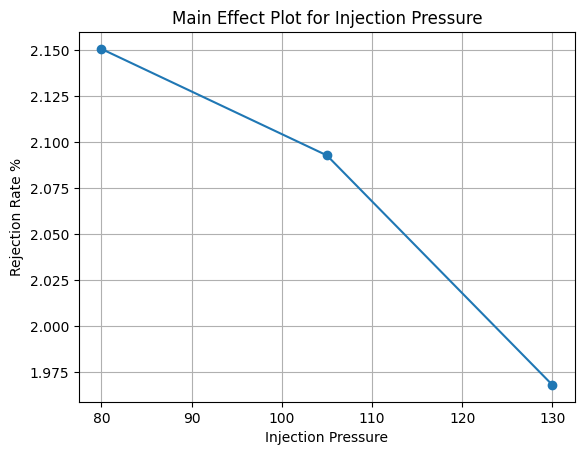

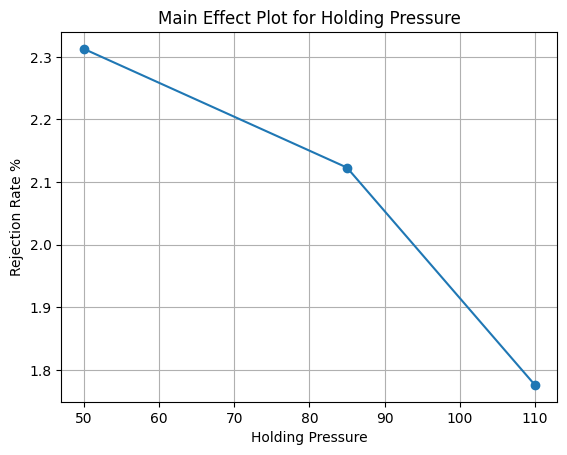

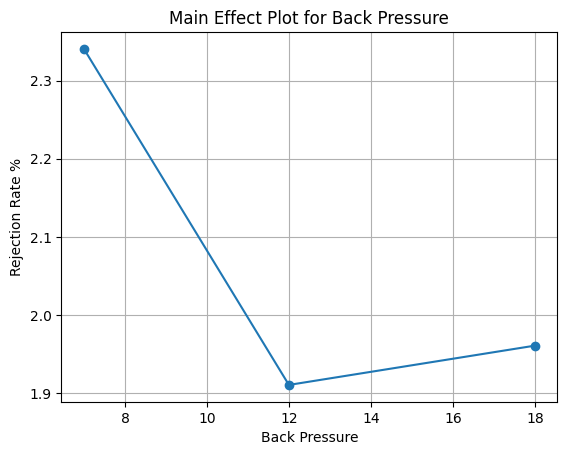

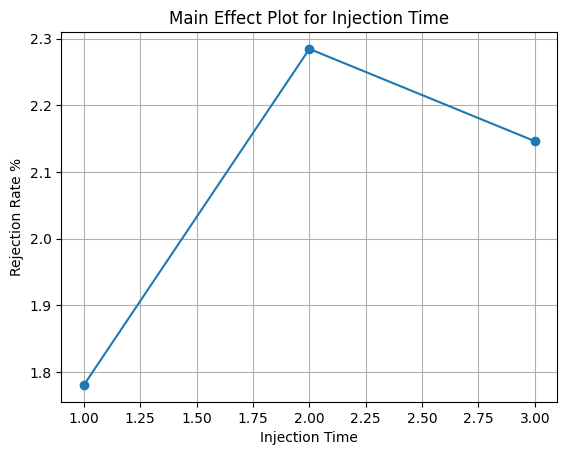

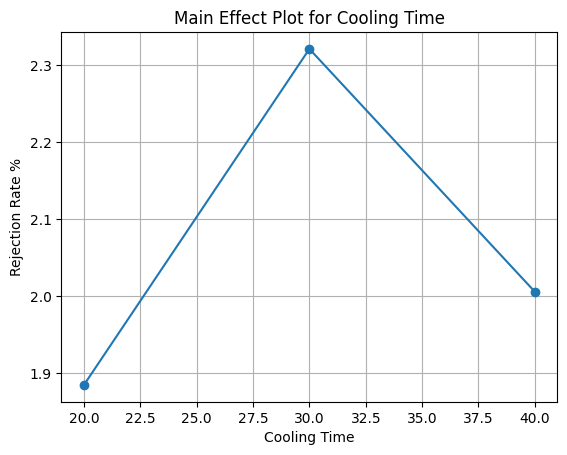

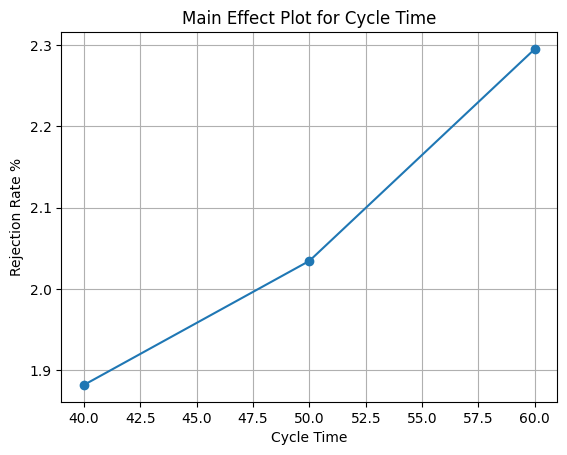

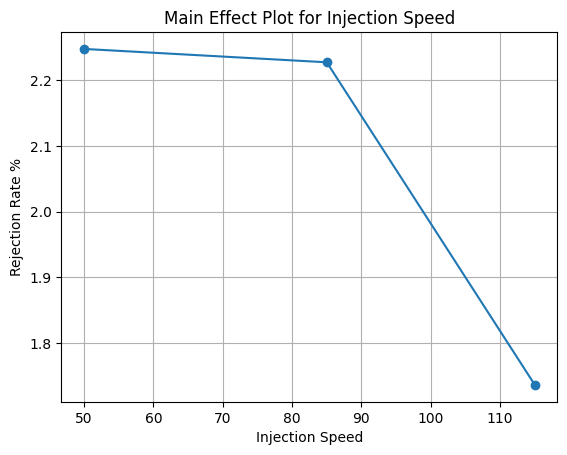

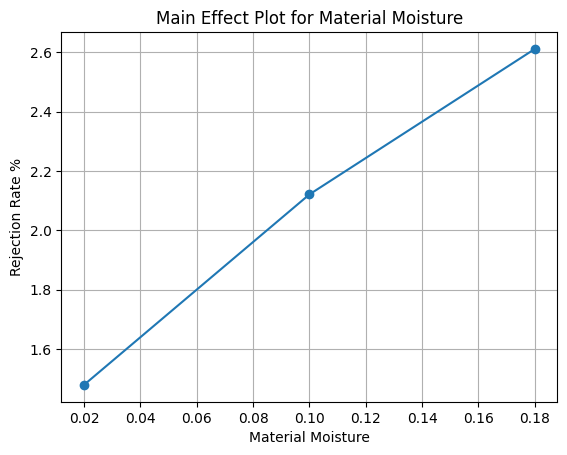

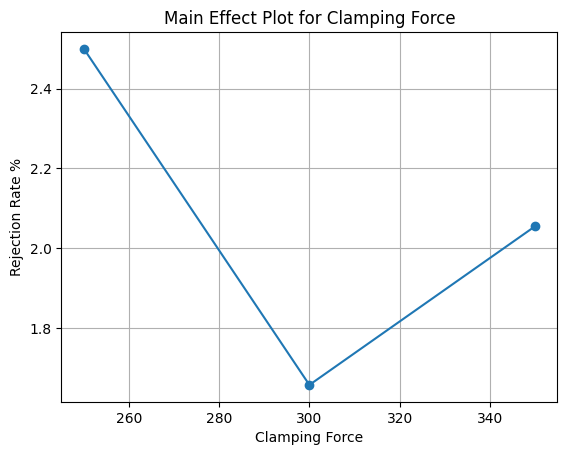

In [11]:
import matplotlib.pyplot as plt

for param in parameters:

    means = avg_df.groupby(param)["Rejection Rate %"].mean()

    plt.figure()

    plt.plot(means.index, means.values, marker='o')

    plt.title(f"Main Effect Plot for {param}")
    plt.xlabel(param)
    plt.ylabel("Rejection Rate %")

    plt.grid()

    plt.show()


In [12]:
confirmation = []

for trial in range(1,6):

    production = int(np.random.normal(35735,3000))

    rejection_rate = np.random.uniform(
        predicted_rejection*0.85,
        predicted_rejection*1.15
    )

    rejection_qty = int(production * rejection_rate /100)

    confirmation.append({

        "Trial":trial,
        "Production":production,
        "Rejection Qty":rejection_qty,
        "Rejection Rate %":rejection_rate

    })

conf_df = pd.DataFrame(confirmation)

conf_df.to_excel(
"/content/Confirmation_Experiment_Industrial.xlsx",
index=False
)

print(conf_df)


   Trial  Production  Rejection Qty  Rejection Rate %
0      1       35927            143          0.398716
1      2       32501            109          0.337396
2      3       33543            107          0.319233
3      4       36384            135          0.372310
4      5       42166            166          0.393858
